# EXAFS Fit Visualization: CsPbI₃ and RbPbI₃ in DMSO
## Publication-Quality Figures for k-space and R-space Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Configure publication-quality plot settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'lines.linewidth': 1.2,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
})

# File paths
data_dir = Path(r"C:\Users\kwill\Keenan_UCB-O365\OneDrive - UCB-O365\Data\XAS\NSLS-II\AthenaProjectFiles\fits")

# Get all .dat files and categorize by type
chiK_files = list(data_dir.glob("*_chiK.dat"))
chiR_files = list(data_dir.glob("*_chiR.dat"))
ReChiR_files = list(data_dir.glob("*_ReChiR.dat"))

print(f"Found {len(chiK_files)} k-space files")
print(f"Found {len(chiR_files)} R-space magnitude files")
print(f"Found {len(ReChiR_files)} R-space real part files")

Found 2 k-space files
Found 2 R-space magnitude files
Found 2 R-space real part files


In [2]:
def parse_athena_dat_file(filepath):
    """
    Parse Athena export .dat files with paired X-Y columns.
    Returns a dictionary with column names as keys and (x_array, y_array) as values.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # Find header line (starts with #  X1)
    header_line = None
    data_start = 0
    sample_name = None
    
    for i, line in enumerate(lines):
        if line.startswith('# Plot Data for'):
            sample_name = line.replace('# Plot Data for', '').strip()
        if line.startswith('#  X1'):
            header_line = line
            data_start = i + 1
            break
    
    # Parse column names from header
    if header_line:
        # Remove leading # and split
        header_clean = header_line.lstrip('#').strip()
        # Column names are the non-X names (X1, X2, etc. are placeholders)
        col_names = [s.strip() for s in re.split(r'\s{2,}', header_clean) if s.strip() and not s.strip().startswith('X')]
    else:
        col_names = []
    
    # Read all numeric data
    data_values = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        # Split by whitespace and convert to floats
        values = [float(v) for v in line.split()]
        data_values.extend(values)
    
    # Data comes in pairs: X1, Y1, X2, Y2, ...
    n_cols = len(col_names)
    data_array = np.array(data_values)
    
    # Determine number of points
    values_per_row = n_cols * 2  # X and Y for each column
    n_points = len(data_array) // values_per_row
    
    # Reshape data
    result = {'sample_name': sample_name}
    for j, col_name in enumerate(col_names):
        x_indices = np.arange(j * 2, n_points * values_per_row, values_per_row)
        y_indices = x_indices + 1
        result[col_name] = {
            'x': data_array[x_indices],
            'y': data_array[y_indices]
        }
    
    return result

# Test parsing
test_data = parse_athena_dat_file(chiR_files[0])
print(f"Sample: {test_data['sample_name']}")
print(f"Columns: {[k for k in test_data.keys() if k != 'sample_name']}")

Sample: 1.0 M CsPbI3 in DMSO (merge 13)_clean
Columns: ['data__mag_', 'model__mag_', 'Pb_I311__mag_', 'Pb_S379__mag_', 'Pb_O258__mag_', 'Pb_S_O404__mag_', 'Pb_I293__mag_', 'Pb_S388__mag_']


In [3]:
# Load all data files
all_data = {
    'chiK': {},
    'chiR': {},
    'ReChiR': {}
}

# Parse chiK files (k-space)
for f in chiK_files:
    data = parse_athena_dat_file(f)
    name = 'CsPbI3' if 'CsPbI3' in f.name else 'RbPbI3'
    all_data['chiK'][name] = data

# Parse chiR files (R-space magnitude)
for f in chiR_files:
    data = parse_athena_dat_file(f)
    name = 'CsPbI3' if 'CsPbI3' in f.name else 'RbPbI3'
    all_data['chiR'][name] = data

# Parse ReChiR files (R-space real part)
for f in ReChiR_files:
    data = parse_athena_dat_file(f)
    name = 'CsPbI3' if 'CsPbI3' in f.name else 'RbPbI3'
    all_data['ReChiR'][name] = data

print("Data loaded successfully!")
for plot_type, samples in all_data.items():
    print(f"\n{plot_type}:")
    for sample_name, data in samples.items():
        cols = [k for k in data.keys() if k != 'sample_name']
        print(f"  {sample_name}: {cols}")

Data loaded successfully!

chiK:
  CsPbI3: ['data', 'model', 'Pb_I311', 'Pb_S379', 'Pb_O258', 'Pb_S_O404', 'Pb_I293', 'Pb_S388']
  RbPbI3: ['data', 'model', 'Pb_S362', 'Pb_I314', 'Pb_O243', 'Pb_S_O373', 'Pb_O274']

chiR:
  CsPbI3: ['data__mag_', 'model__mag_', 'Pb_I311__mag_', 'Pb_S379__mag_', 'Pb_O258__mag_', 'Pb_S_O404__mag_', 'Pb_I293__mag_', 'Pb_S388__mag_']
  RbPbI3: ['data__mag_', 'model__mag_', 'Pb_S362__mag_', 'Pb_I314__mag_', 'Pb_O243__mag_', 'Pb_S_O373__mag_', 'Pb_O274__mag_']

ReChiR:
  CsPbI3: ['data__real_', 'model__real_', 'Pb_I311__real_', 'Pb_S379__real_', 'Pb_O258__real_', 'Pb_S_O404__real_', 'Pb_I293__real_', 'Pb_S388__real_']
  RbPbI3: ['data__real_', 'model__real_', 'Pb_S362__real_', 'Pb_I314__real_', 'Pb_O243__real_', 'Pb_S_O373__real_', 'Pb_O274__real_']


## Parse Fit Results and Extract Parameters

In [14]:
def parse_feffit_results(filepath):
    """
    Parse Larch/Artemis FEFFIT results .txt file.
    Returns dictionary with fit statistics and path parameters.
    """
    with open(filepath, 'r') as f:
        content = f.read()
    
    results = {
        'statistics': {},
        'paths': {}
    }
    
    # Extract statistics
    stats_patterns = {
        'r_factor': r'r-factor\s*=\s*([\d.e+-]+)',
        'reduced_chi_sq': r'reduced chi_square\s*=\s*([\d.e+-]+)',
        'n_variables': r'n_variables\s*=\s*(\d+)',
        'n_independent': r'n_independent\s*=\s*([\d.]+)',
    }
    
    for key, pattern in stats_patterns.items():
        match = re.search(pattern, content)
        if match:
            results['statistics'][key] = float(match.group(1))
    
    # Extract e0 and s02
    e0_match = re.search(r"e0\s*=\s*([\d.e+-]+)\s*\+/-\s*([\d.e+-]+)", content)
    if e0_match:
        results['e0'] = {'value': float(e0_match.group(1)), 'error': float(e0_match.group(2))}
    
    s02_match = re.search(r"s02\s*=\s*([\d.e+-]+)\s*\(fixed\)", content)
    if s02_match:
        results['s02'] = float(s02_match.group(1))
    
    # Extract path information
    path_sections = re.split(r"= Path '(\w+)'", content)
    
    for i in range(1, len(path_sections), 2):
        path_name = path_sections[i]
        path_content = path_sections[i+1] if i+1 < len(path_sections) else ""
        
        path_info = {}
        
        # Extract n*s02 (coordination number * amplitude factor)
        ns02_match = re.search(r"n\*s02\s*=\s*([\d.e+-]+)\s*\+/-\s*([\d.e+-]+)", path_content)
        if ns02_match:
            path_info['n_s02'] = {'value': float(ns02_match.group(1)), 'error': float(ns02_match.group(2))}
        else:
            ns02_fixed = re.search(r"n\*s02\s*=\s*([\d.e+-]+)\s*:=", path_content)
            if ns02_fixed:
                path_info['n_s02'] = {'value': float(ns02_fixed.group(1)), 'error': None}
        
        # Extract r (real distance)
        r_match = re.search(r"\n\s+r\s*=\s*([\d.e+-]+)\s*\+/-\s*([\d.e+-]+)", path_content)
        if r_match:
            path_info['r'] = {'value': float(r_match.group(1)), 'error': float(r_match.group(2))}
        else:
            r_fixed = re.search(r"\n\s+r\s*=\s*([\d.e+-]+)\s*:=", path_content)
            if r_fixed:
                path_info['r'] = {'value': float(r_fixed.group(1)), 'error': None}
        
        # Extract sigma2
        sigma2_match = re.search(r"sigma2\s*=\s*([\d.e+-]+)\s*\+/-\s*([\d.e+-]+)", path_content)
        if sigma2_match:
            path_info['sigma2'] = {'value': float(sigma2_match.group(1)), 'error': float(sigma2_match.group(2))}
        else:
            sigma2_fixed = re.search(r"sigma2\s*=\s*([\d.e+-]+)\s*:=", path_content)
            if sigma2_fixed:
                path_info['sigma2'] = {'value': float(sigma2_fixed.group(1)), 'error': None}
        
        # Extract scatterer type from path name
        if 'I' in path_name:
            path_info['scatterer'] = 'I'
        elif 'S_O' in path_name:
            path_info['scatterer'] = 'S–O (MS)'
        elif 'S' in path_name:
            path_info['scatterer'] = 'S'
        elif 'O' in path_name:
            path_info['scatterer'] = 'O'
        else:
            path_info['scatterer'] = 'Unknown'
        
        results['paths'][path_name] = path_info
    
    return results

# Parse fit results files
fit_files = {
    'CsPbI3': data_dir / '1_0_M_CsPbI3_in_DMSO_merge_13_clean_Feb-26_00_27.txt',
    'RbPbI3': data_dir / 'RbPbI3-DMSO_1p0M_merge_abscorr_Feb-26_10_31.txt'
}

fit_results = {}
for sample, filepath in fit_files.items():
    if filepath.exists():
        fit_results[sample] = parse_feffit_results(filepath)
        print(f"\n{sample} fit results loaded:")
        print(f"  R-factor: {fit_results[sample]['statistics'].get('r_factor', 'N/A'):.4f}")
        print(f"  Reduced χ²: {fit_results[sample]['statistics'].get('reduced_chi_sq', 'N/A'):.2f}")
        print(f"  Paths: {list(fit_results[sample]['paths'].keys())}")


CsPbI3 fit results loaded:
  R-factor: 0.0235
  Reduced χ²: 17.13
  Paths: ['Pb_I311', 'Pb_S379', 'Pb_O258', 'Pb_S_O404', 'Pb_I293', 'Pb_S388']

RbPbI3 fit results loaded:
  R-factor: 0.0684
  Reduced χ²: 1085365.62
  Paths: ['Pb_S362', 'Pb_I314', 'Pb_O243', 'Pb_S_O373', 'Pb_O274']


In [15]:
import pandas as pd

def format_val_err(val, err, decimals=4):
    """Format value ± error string"""
    if err is None:
        return f"{val:.{decimals}f} (fixed)"
    return f"{val:.{decimals}f} ± {err:.{decimals}f}"

# Create DataFrames for each sample
tables = {}
for sample, results in fit_results.items():
    rows = []
    s02 = results.get('s02', 0.78)
    
    for path_name, path_info in results['paths'].items():
        # Calculate N from n*s02
        n_s02 = path_info.get('n_s02', {})
        if n_s02:
            n_val = n_s02.get('value', 0) / s02
            n_err = n_s02.get('error')
            if n_err:
                n_err = n_err / s02
        else:
            n_val, n_err = None, None
        
        r_info = path_info.get('r', {})
        sigma2_info = path_info.get('sigma2', {})
        
        row = {
            'Path': path_name.replace('_', '–'),
            'Scatterer': path_info.get('scatterer', ''),
            'N': format_val_err(n_val, n_err, 2) if n_val else '—',
            'R (Å)': format_val_err(r_info.get('value', 0), r_info.get('error'), 3) if r_info else '—',
            'σ² (Å²)': format_val_err(sigma2_info.get('value', 0), sigma2_info.get('error'), 4) if sigma2_info else '—',
        }
        rows.append(row)
    
    tables[sample] = pd.DataFrame(rows)
    
# Display tables
for sample, df in tables.items():
    print(f"\n{'='*60}")
    print(f"EXAFS Fit Parameters: {sample_labels.get(sample, sample)}")
    print(f"{'='*60}")
    print(f"S₀² = {fit_results[sample].get('s02', 'N/A')} (fixed)")
    e0_info = fit_results[sample].get('e0', {})
    if e0_info:
        print(f"E₀ = {e0_info.get('value', 0):.2f} ± {e0_info.get('error', 0):.2f} eV")
    print(f"R-factor = {fit_results[sample]['statistics'].get('r_factor', 0):.4f}")
    print()
    print(df.to_string(index=False))
    print()


EXAFS Fit Parameters: CsPbI$_3$
S₀² = 0.78 (fixed)
E₀ = -3.28 ± 0.95 eV
R-factor = 0.0235

     Path Scatterer            N         R (Å)         σ² (Å²)
  Pb–I311         I  3.43 ± 0.73 3.052 ± 0.018 0.0129 ± 0.0014
  Pb–S379         S 1.00 (fixed) 3.689 ± 0.046 0.0094 ± 0.0081
  Pb–O258         O  0.49 ± 0.23 2.510 ± 0.045 0.0039 ± 0.0035
Pb–S–O404  S–O (MS)  0.49 ± 0.23 4.194 ± 0.406 0.0067 ± 0.0039
  Pb–I293         I 1.00 (fixed) 2.827 (fixed) 0.0126 ± 0.0034
  Pb–S388         S 1.00 (fixed) 3.495 ± 0.077 0.0094 ± 0.0081


EXAFS Fit Parameters: RbPbI$_3$
S₀² = 0.78 (fixed)
E₀ = 1.30 ± 1.46 eV
R-factor = 0.0684

     Path Scatterer           N         R (Å)         σ² (Å²)
  Pb–S362         S 3.69 ± 1.55 3.691 ± 0.124 0.0258 ± 0.0199
  Pb–I314         I 2.60 ± 0.33 3.087 (fixed)  0.0071 (fixed)
  Pb–O243         O 1.84 ± 0.77 2.509 (fixed) 0.0070 ± 0.0034
Pb–S–O373  S–O (MS) 3.69 ± 1.55 3.759 (fixed) 0.0070 ± 0.0034
  Pb–O274         O 1.84 ± 0.77 2.692 ± 0.028 0.0070 ± 0.0034



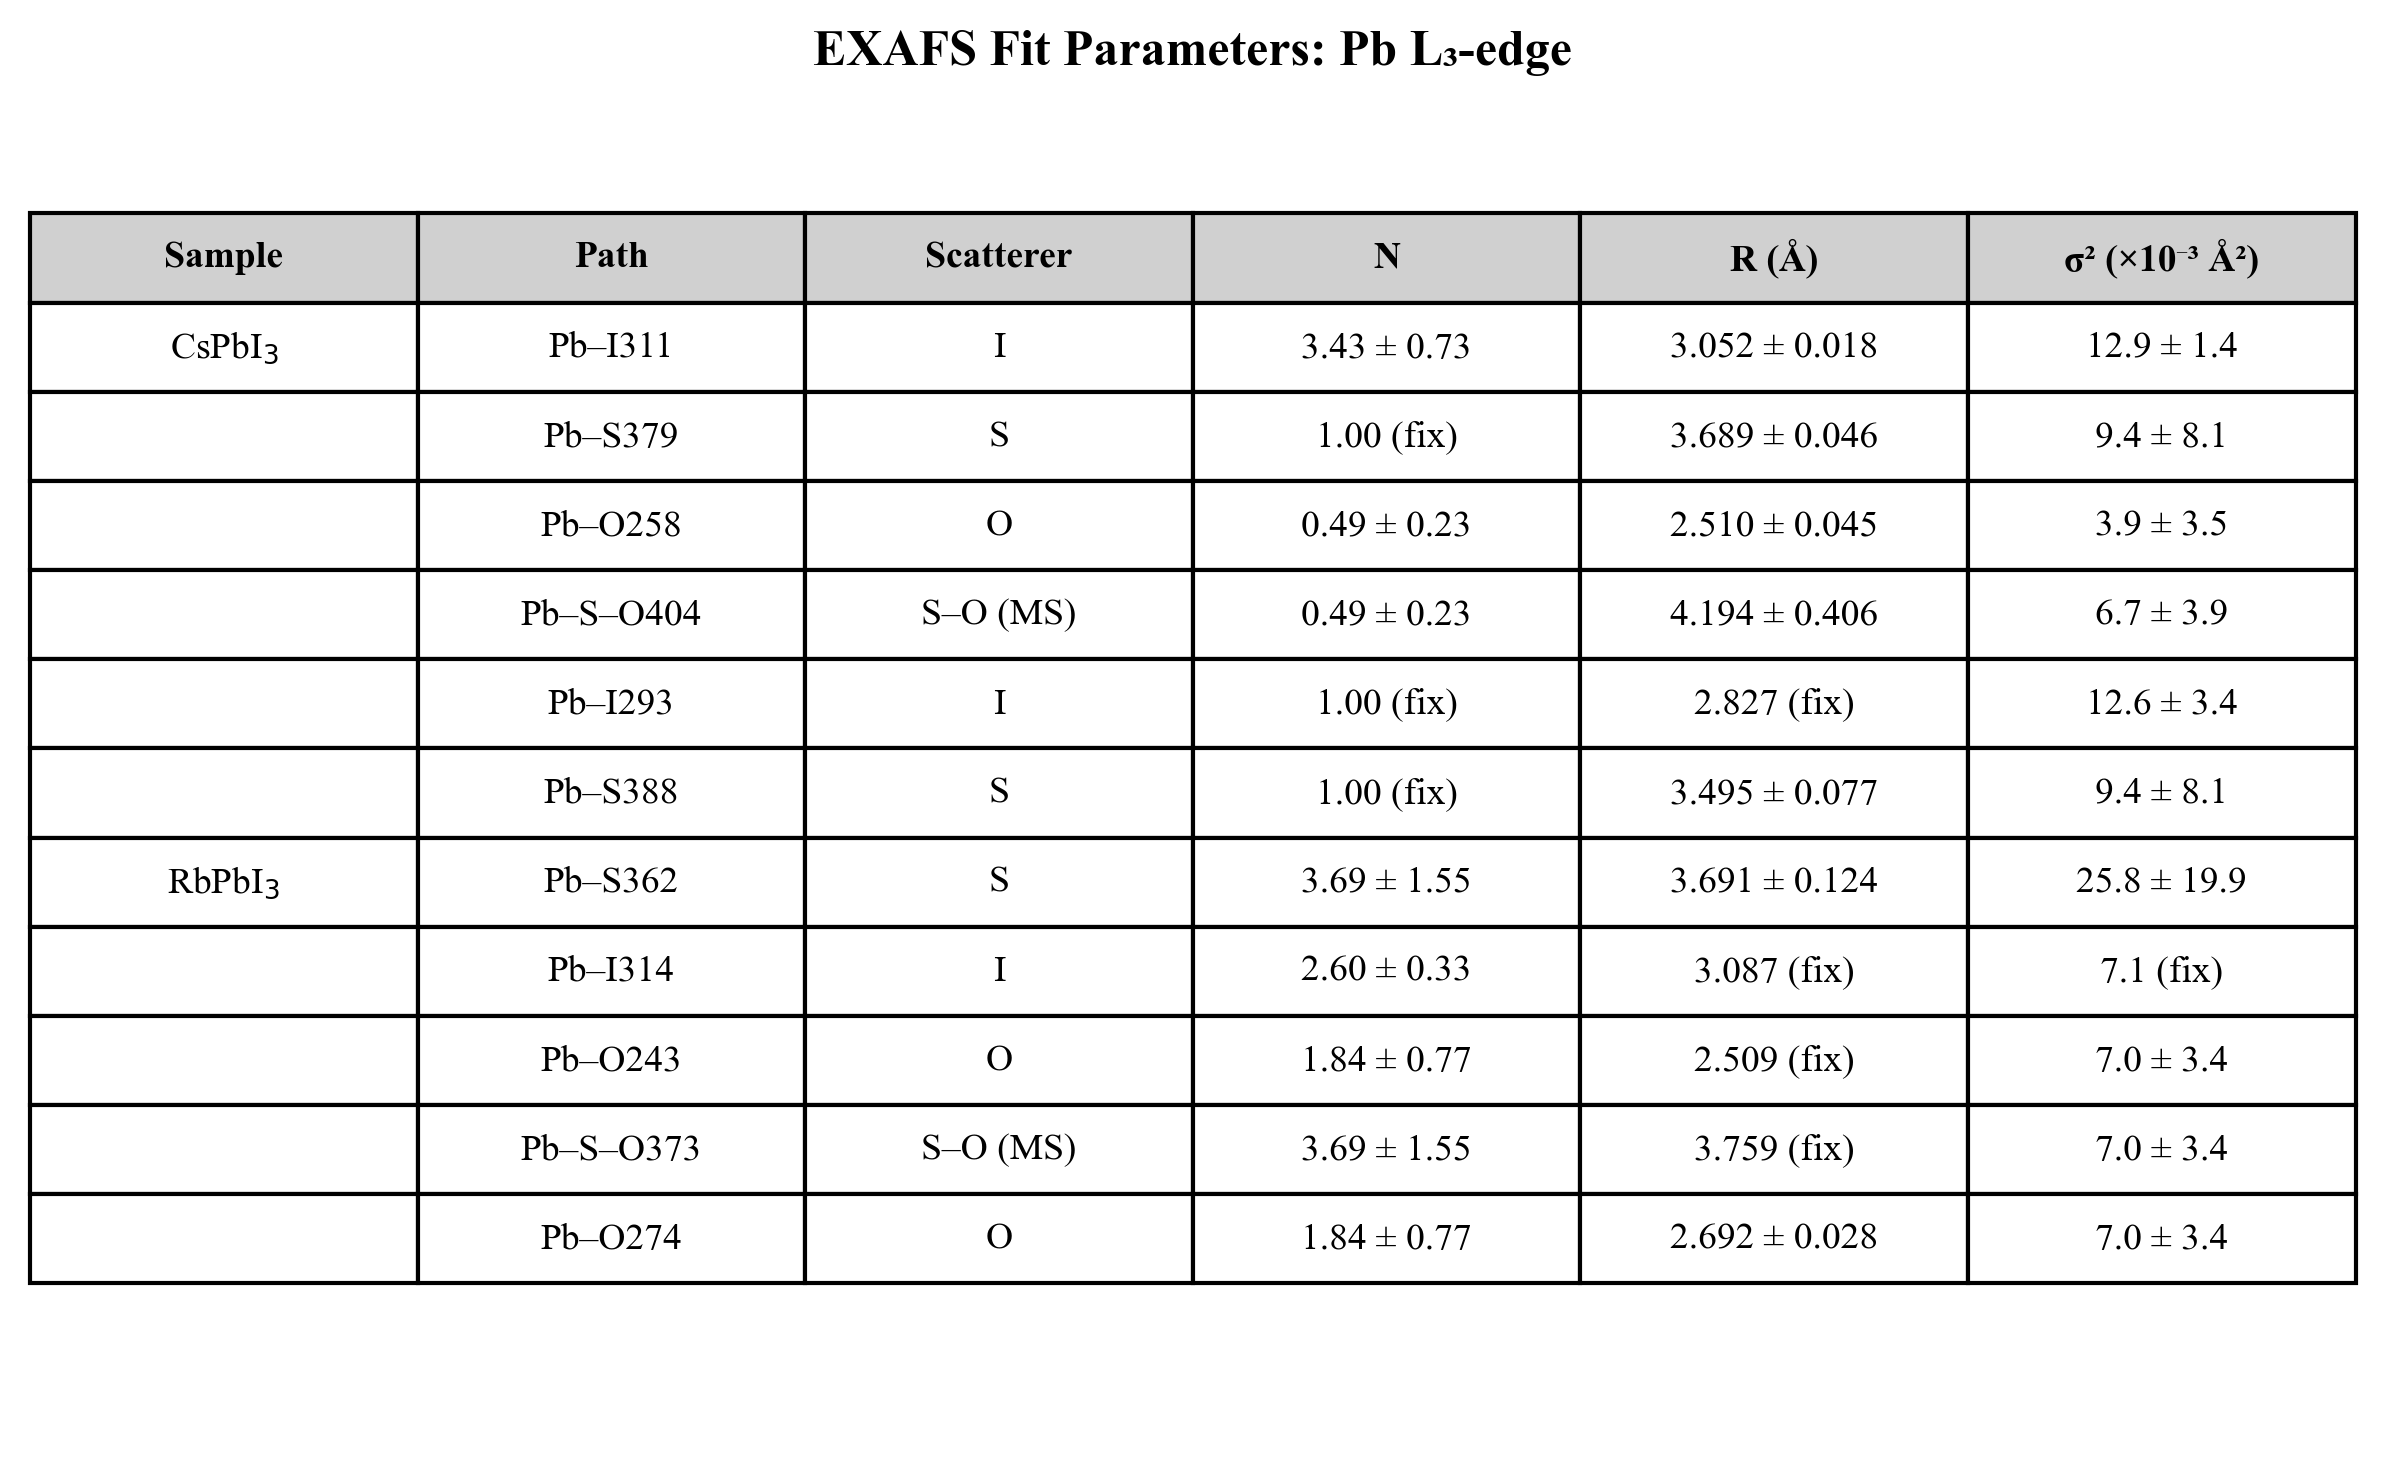

Saved: C:\Users\kwill\Keenan_UCB-O365\OneDrive - UCB-O365\Data\XAS\NSLS-II\AthenaProjectFiles\fits\Table_EXAFS_fit_parameters.png


In [16]:
# Create a publication-quality figure with fit parameters table
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')

# Build combined table data
table_data = []
header = ['Sample', 'Path', 'Scatterer', 'N', 'R (Å)', 'σ² (×10⁻³ Å²)']

for sample in ['CsPbI3', 'RbPbI3']:
    if sample not in fit_results:
        continue
    results = fit_results[sample]
    s02 = results.get('s02', 0.78)
    
    first_row = True
    for path_name, path_info in results['paths'].items():
        # Calculate N from n*s02
        n_s02 = path_info.get('n_s02', {})
        if n_s02:
            n_val = n_s02.get('value', 0) / s02
            n_err = n_s02.get('error')
            n_str = f"{n_val:.2f}" + (f" ± {n_err/s02:.2f}" if n_err else " (fix)")
        else:
            n_str = '—'
        
        r_info = path_info.get('r', {})
        if r_info:
            r_str = f"{r_info.get('value', 0):.3f}" + (f" ± {r_info.get('error', 0):.3f}" if r_info.get('error') else " (fix)")
        else:
            r_str = '—'
        
        sigma2_info = path_info.get('sigma2', {})
        if sigma2_info:
            s2_val = sigma2_info.get('value', 0) * 1000  # Convert to 10^-3 Å²
            s2_err = sigma2_info.get('error')
            s2_str = f"{s2_val:.1f}" + (f" ± {s2_err*1000:.1f}" if s2_err else " (fix)")
        else:
            s2_str = '—'
        
        sample_label = sample_labels.get(sample, sample) if first_row else ''
        first_row = False
        
        table_data.append([
            sample_label,
            path_name.replace('_', '–'),
            path_info.get('scatterer', ''),
            n_str,
            r_str,
            s2_str
        ])

# Create table
table = ax.table(
    cellText=table_data,
    colLabels=header,
    loc='center',
    cellLoc='center',
    colColours=['#f0f0f0'] * len(header)
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

# Style header
for i in range(len(header)):
    table[(0, i)].set_text_props(fontweight='bold')
    table[(0, i)].set_facecolor('#d0d0d0')

# Add title
plt.title('EXAFS Fit Parameters: Pb L₃-edge', fontsize=12, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig(data_dir / 'Table_EXAFS_fit_parameters.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(data_dir / 'Table_EXAFS_fit_parameters.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {data_dir / 'Table_EXAFS_fit_parameters.png'}")

## Figure 1: k-space EXAFS fits (χ(k))

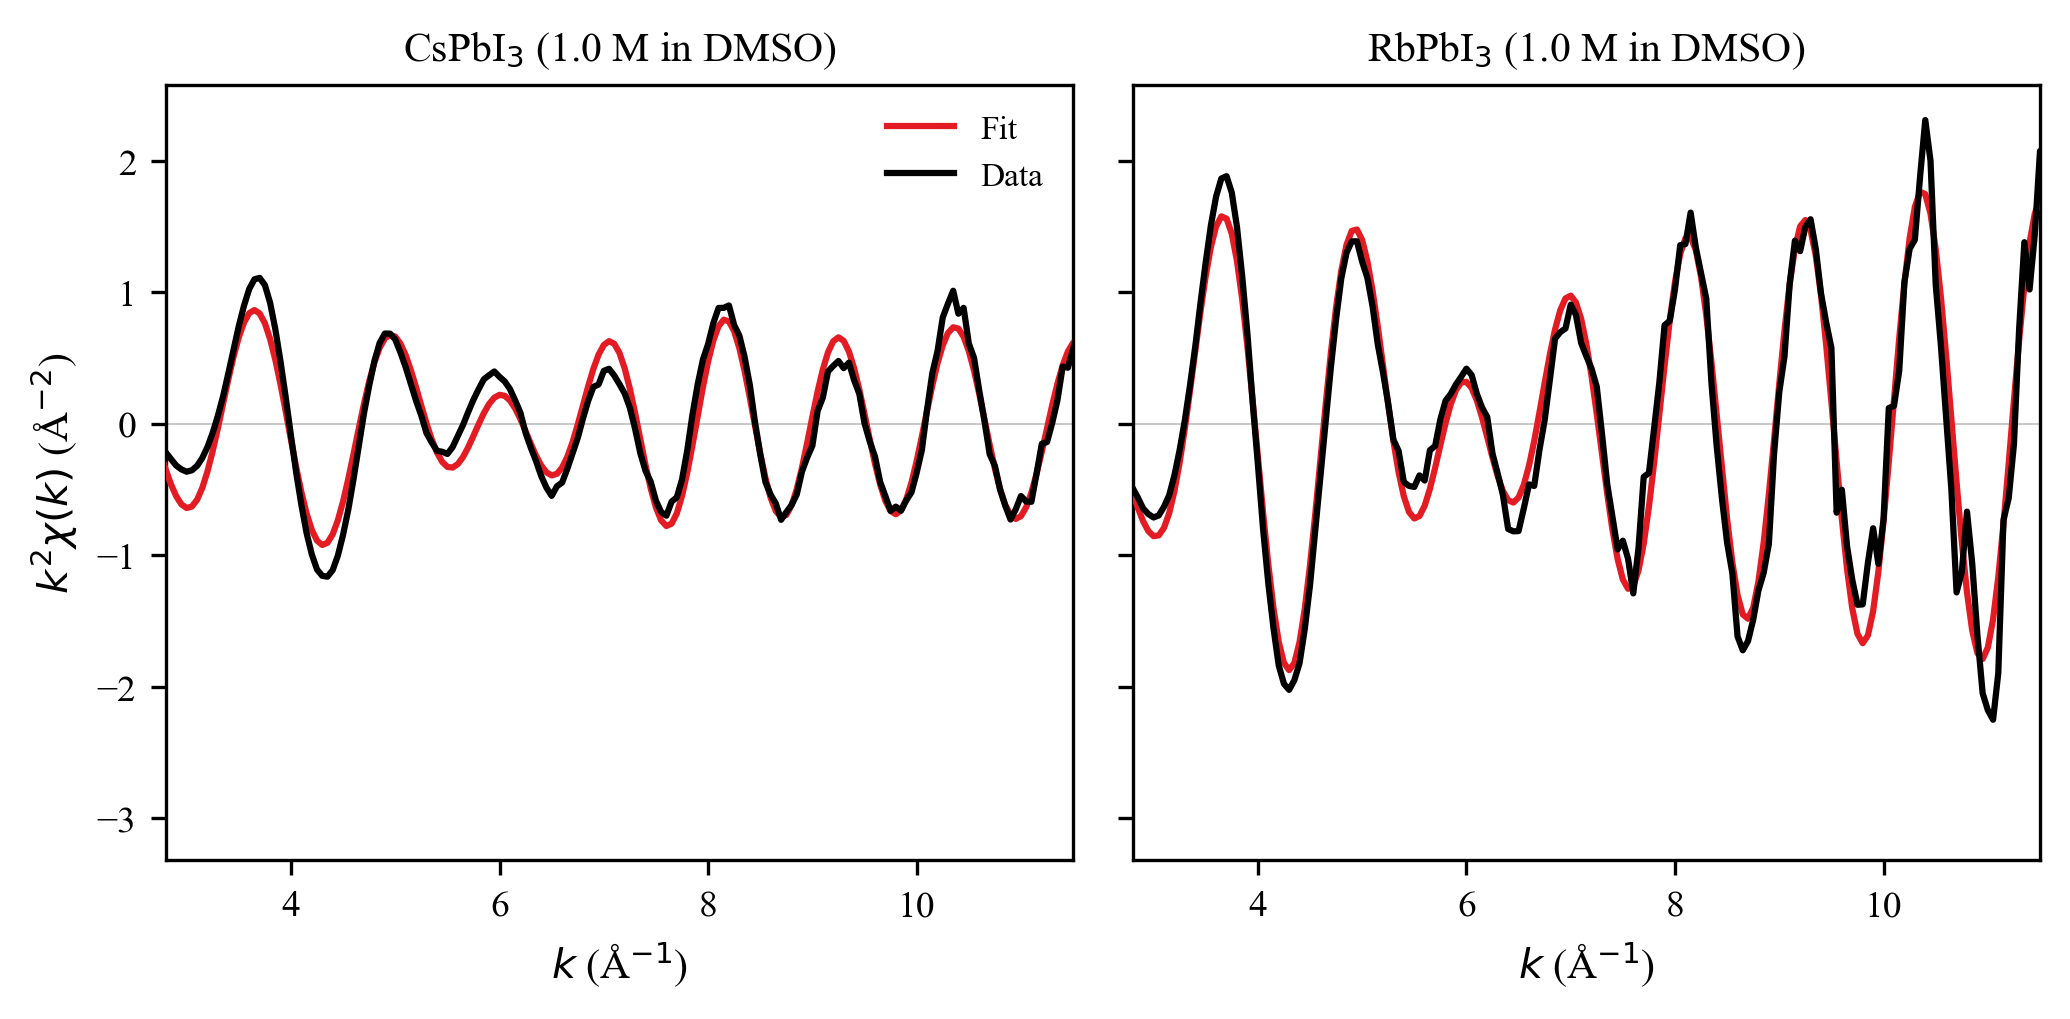

Saved: C:\Users\kwill\Keenan_UCB-O365\OneDrive - UCB-O365\Data\XAS\NSLS-II\AthenaProjectFiles\fits\Figure_kspace_EXAFS.png


In [28]:
# Publication-quality color palette (colorblind-friendly)
colors = {
    'data': '#000000',      # Black for experimental data
    'model': '#E31B23',     # Red for model fit
    'Pb_I': '#1E88E5',      # Blue for Pb-I paths
    'Pb_S': '#43A047',      # Green for Pb-S paths
    'Pb_O': '#FB8C00',      # Orange for Pb-O paths
    'Pb_S_O': '#8E24AA',    # Purple for Pb-S/O mixed paths
}

def get_path_color(col_name):
    """Assign colors based on path type"""
    if col_name in ['data', 'data_']:
        return colors['data']
    elif col_name == 'model' or col_name == 'model_':
        return colors['model']
    elif 'Pb_I' in col_name:
        return colors['Pb_I']
    elif 'Pb_S_O' in col_name or 'S_O' in col_name:
        return colors['Pb_S_O']
    elif 'Pb_S' in col_name:
        return colors['Pb_S']
    elif 'Pb_O' in col_name:
        return colors['Pb_O']
    else:
        return '#666666'

def format_path_label(col_name, sample):
    """Format path names for legend"""
    col_clean = col_name.replace('__mag_', '').replace('__real_', '').replace('_', '-').strip('-')
    if col_clean in ['data', 'data-']:
        return 'Data'
    elif col_clean == 'model' or col_clean == 'model-':
        return 'Fit'
    else:
        return col_clean.replace('Pb-', 'Pb–')

sample_labels = {'CsPbI3': r'CsPbI$_3$', 'RbPbI3': r'RbPbI$_3$'}

# Create k-space figure: data + fit only (no path contributions)
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), sharey=True)

for idx, (sample, ax) in enumerate(zip(['CsPbI3', 'RbPbI3'], axes)):
    if sample not in all_data['chiK']:
        continue
    
    data_dict = all_data['chiK'][sample]
    
    # Find data and model columns only
    data_col = None
    model_col = None
    
    for col in data_dict.keys():
        if col == 'sample_name':
            continue
        if col in ['data', 'data_']:
            data_col = col
        elif col in ['model', 'model_']:
            model_col = col
    
    # Plot model fit first (so data is on top)
    if model_col:
        x = data_dict[model_col]['x']
        y = data_dict[model_col]['y']
        ax.plot(x, y, color=colors['model'], linewidth=1.5, 
                linestyle='-', label='Fit', zorder=10)
    
    # Plot data (line only)
    if data_col:
        x = data_dict[data_col]['x']
        y = data_dict[data_col]['y']
        ax.plot(x, y, color=colors['data'], linewidth=1.5, label='Data', zorder=12)
    
    ax.set_xlabel(r'$k$ (Å$^{-1}$)')
    ax.set_title(f'{sample_labels[sample]} (1.0 M in DMSO)', fontsize=10, fontweight='medium')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.4, alpha=0.5)
    
    # Set axis limits
    ax.set_xlim(2.8, 11.5)
    
    # Add legend
    if idx == 0:
        ax.legend(loc='upper right', frameon=True, framealpha=0.95, edgecolor='none')

axes[0].set_ylabel(r'$k^2\chi(k)$ (Å$^{-2}$)')

plt.tight_layout()
plt.savefig(data_dir / 'Figure_kspace_EXAFS.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(data_dir / 'Figure_kspace_EXAFS.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {data_dir / 'Figure_kspace_EXAFS.png'}")

## Figure 2: R-space EXAFS fits |χ(R)|

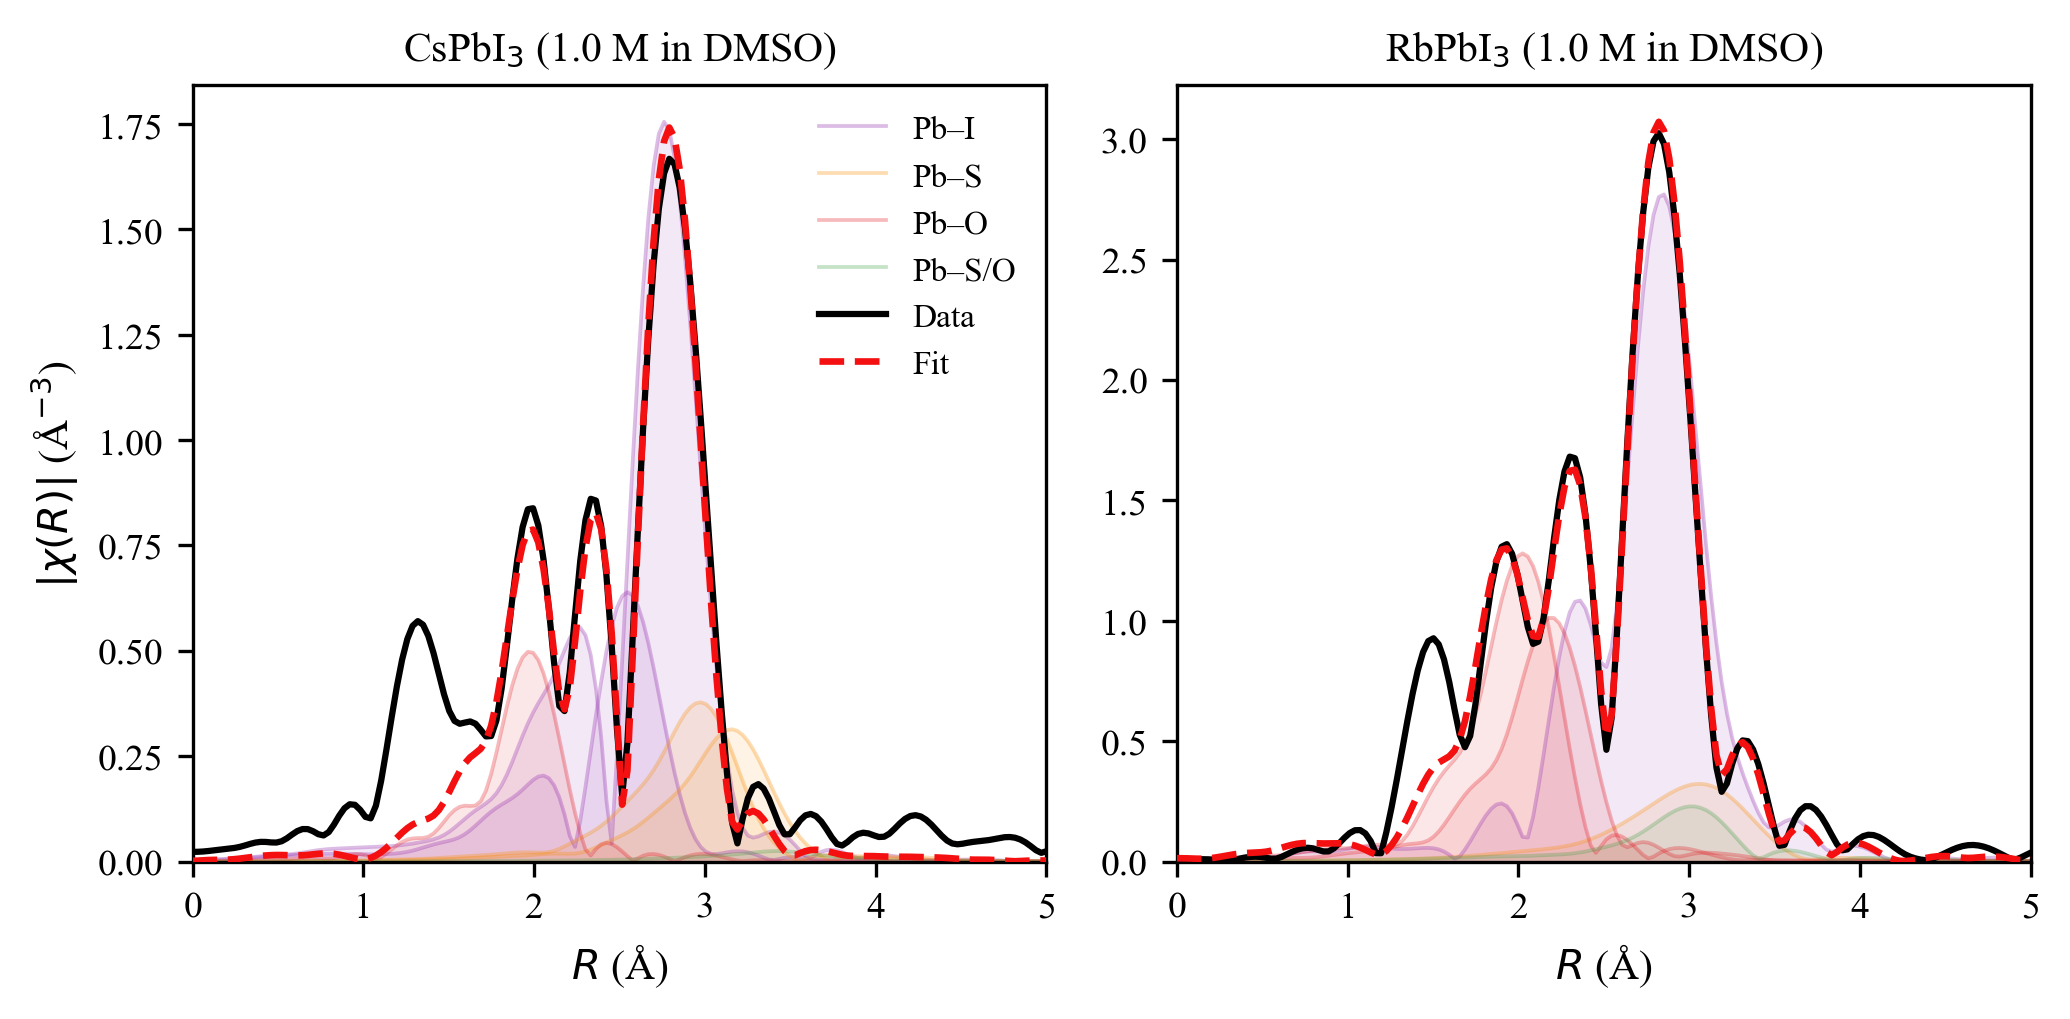

Saved: C:\Users\kwill\Keenan_UCB-O365\OneDrive - UCB-O365\Data\XAS\NSLS-II\AthenaProjectFiles\fits\Figure_Rspace_magnitude_EXAFS.png


In [29]:
# Create R-space magnitude figure with updated colors and legend
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), sharey=False)

# Updated color scheme
path_colors = {
    'Pb–I': '#8E24AA',      # Purple for Pb-I
    'Pb–O': '#E31B23',      # Red for Pb-O
    'Pb–S': '#FB8C00',      # Orange for Pb-S
    'Pb–S/O': '#43A047',    # Green for mixed MS paths
}

for idx, (sample, ax) in enumerate(zip(['CsPbI3', 'RbPbI3'], axes)):
    if sample not in all_data['chiR']:
        continue
    
    data_dict = all_data['chiR'][sample]
    
    # Categorize columns by path type
    paths_by_type = {}
    data_col = None
    model_col = None
    
    for col in data_dict.keys():
        if col == 'sample_name':
            continue
        col_lower = col.lower()
        if 'data' in col_lower:
            data_col = col
        elif 'model' in col_lower:
            model_col = col
        else:
            # Categorize by path type
            if 'S_O' in col or 'S-O' in col:
                paths_by_type.setdefault('Pb–S/O', []).append(col)
            elif 'Pb_I' in col or 'Pb-I' in col:
                paths_by_type.setdefault('Pb–I', []).append(col)
            elif 'Pb_S' in col or 'Pb-S' in col:
                paths_by_type.setdefault('Pb–S', []).append(col)
            elif 'Pb_O' in col or 'Pb-O' in col:
                paths_by_type.setdefault('Pb–O', []).append(col)
    
    # Plot individual scattering paths grouped by type (with increased transparency)
    plotted_types = set()
    for path_type, cols in paths_by_type.items():
        color = path_colors.get(path_type, '#666666')
        for col in cols:
            x = data_dict[col]['x']
            y = data_dict[col]['y']
            # Only add label for first path of each type
            label = path_type if path_type not in plotted_types else None
            ax.fill_between(x, 0, y, color=color, alpha=0.1, linewidth=0)
            ax.plot(x, y, color=color, linewidth=0.9, 
                    alpha=0.3, label=label, zorder=2)
            plotted_types.add(path_type)
    
    # Plot data (line only)
    if data_col:
        x = data_dict[data_col]['x']
        y = data_dict[data_col]['y']
        ax.plot(x, y, color=colors['data'], linewidth=1.5, label='Data', zorder=5)
    
    # Plot model fit (on top)
    if model_col:
        x = data_dict[model_col]['x']
        y = data_dict[model_col]['y']
        ax.plot(x, y, color="#F41010", linewidth=1.6, 
                linestyle='--', label='Fit', zorder=10)
    
    ax.set_xlabel(r'$R$ (Å)')
    ax.set_title(f'{sample_labels[sample]} (1.0 M in DMSO)', fontsize=10, fontweight='medium')
    ax.set_xlim(0, 5)
    ax.set_ylim(bottom=0)
    
    # Legend for first panel only with unique path types
    if idx == 0:
        ax.legend(loc='upper right', frameon=True, framealpha=0.95, edgecolor='none', ncol=1)

axes[0].set_ylabel(r'$|\chi(R)|$ (Å$^{-3}$)')

plt.tight_layout()
plt.savefig(data_dir / 'Figure_Rspace_magnitude_EXAFS.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(data_dir / 'Figure_Rspace_magnitude_EXAFS.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {data_dir / 'Figure_Rspace_magnitude_EXAFS.png'}")

## Figure 3: R-space Real Part Re[χ(R)]

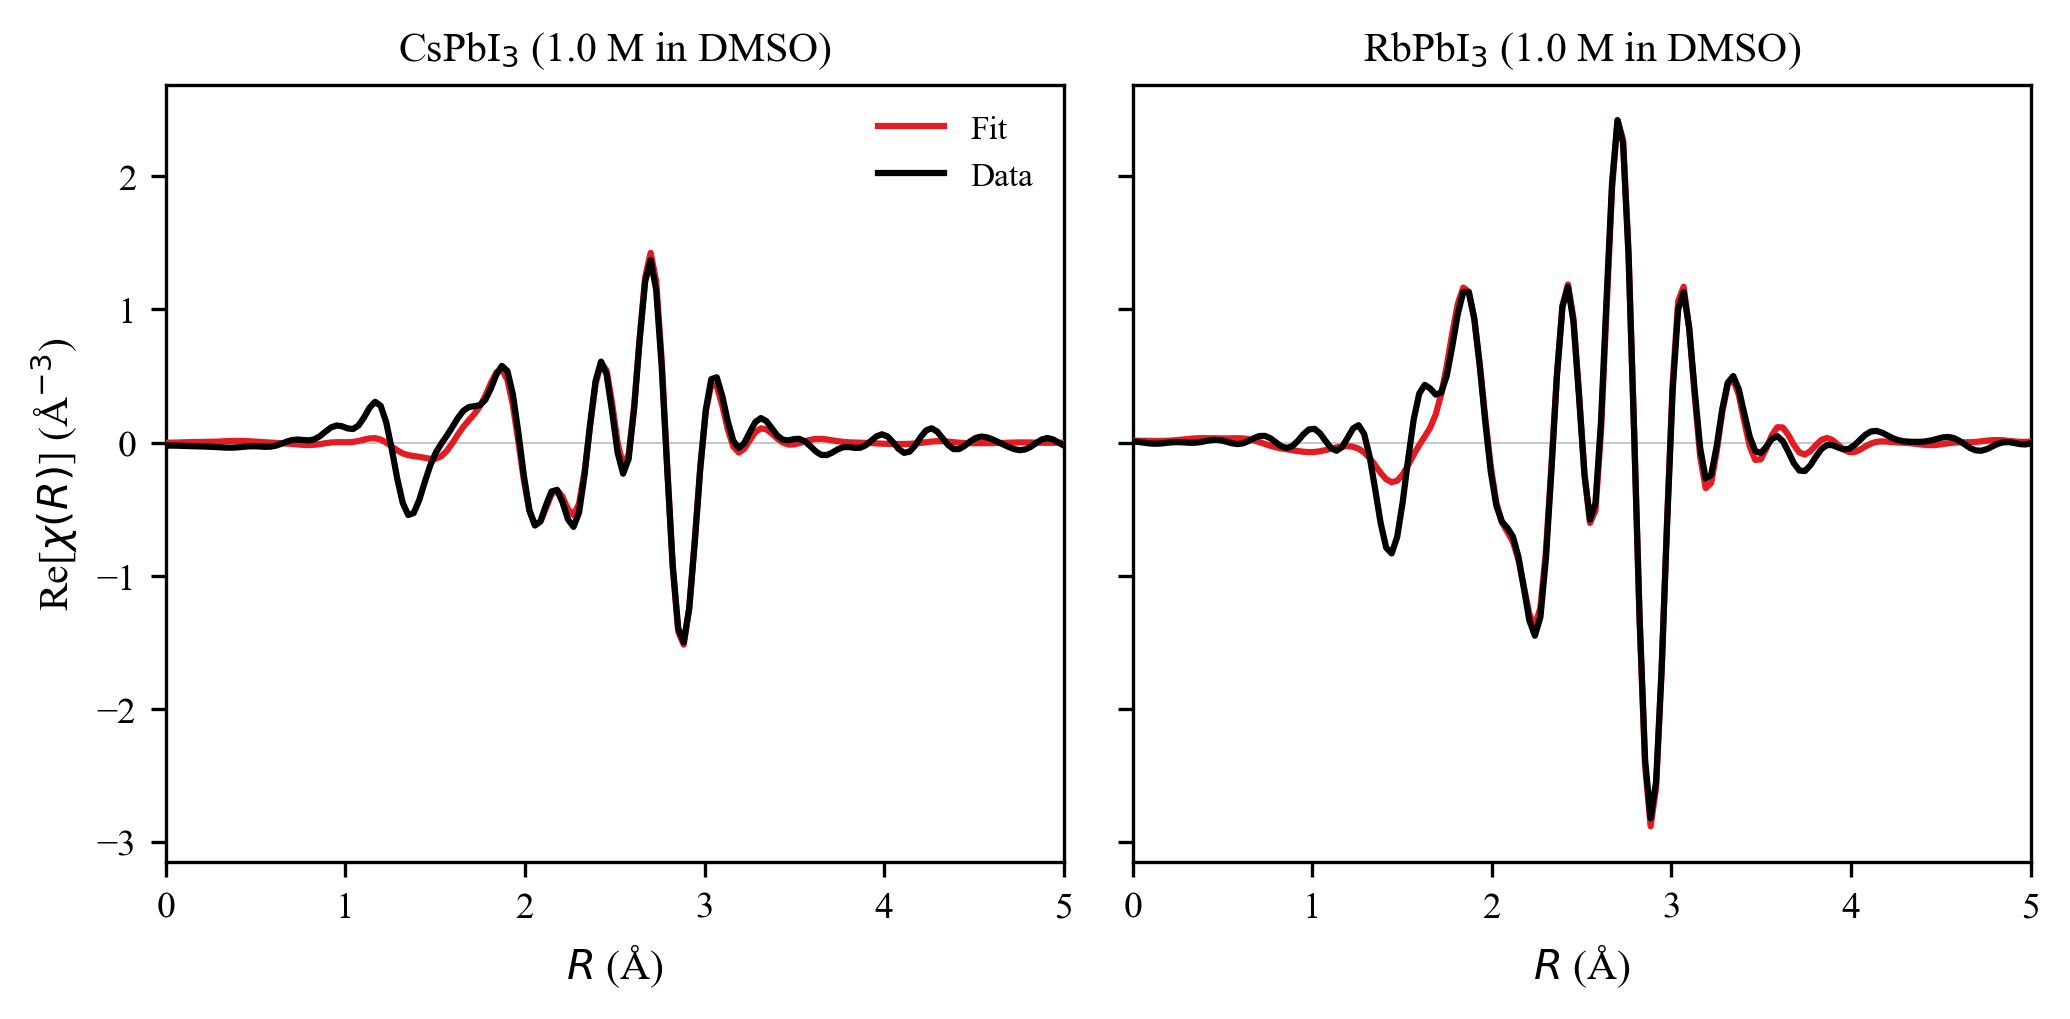

Saved: C:\Users\kwill\Keenan_UCB-O365\OneDrive - UCB-O365\Data\XAS\NSLS-II\AthenaProjectFiles\fits\Figure_Rspace_real_EXAFS.png


In [30]:
# Create R-space real part figure: data + fit only (no path contributions)
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), sharey=True)

for idx, (sample, ax) in enumerate(zip(['CsPbI3', 'RbPbI3'], axes)):
    if sample not in all_data['ReChiR']:
        continue
    
    data_dict = all_data['ReChiR'][sample]
    
    # Identify data and model columns only
    data_col = None
    model_col = None
    
    for col in data_dict.keys():
        if col == 'sample_name':
            continue
        col_lower = col.lower()
        if 'data' in col_lower:
            data_col = col
        elif 'model' in col_lower:
            model_col = col
    
    # Plot model fit first
    if model_col:
        x = data_dict[model_col]['x']
        y = data_dict[model_col]['y']
        ax.plot(x, y, color=colors['model'], linewidth=1.5, 
                linestyle='-', label='Fit', zorder=10)
    
    # Plot data (line only)
    if data_col:
        x = data_dict[data_col]['x']
        y = data_dict[data_col]['y']
        ax.plot(x, y, color=colors['data'], linewidth=1.5, label='Data', zorder=12)
    
    ax.set_xlabel(r'$R$ (Å)')
    ax.set_title(f'{sample_labels[sample]} (1.0 M in DMSO)', fontsize=10, fontweight='medium')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.4, alpha=0.5)
    ax.set_xlim(0, 5)
    
    # Legend for first panel
    if idx == 0:
        ax.legend(loc='upper right', frameon=True, framealpha=0.95, edgecolor='none')

axes[0].set_ylabel(r'Re[$\chi(R)$] (Å$^{-3}$)')

plt.tight_layout()
plt.savefig(data_dir / 'Figure_Rspace_real_EXAFS.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(data_dir / 'Figure_Rspace_real_EXAFS.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {data_dir / 'Figure_Rspace_real_EXAFS.png'}")

## Figure 4: Combined Publication Figure (Data vs Fit comparison)

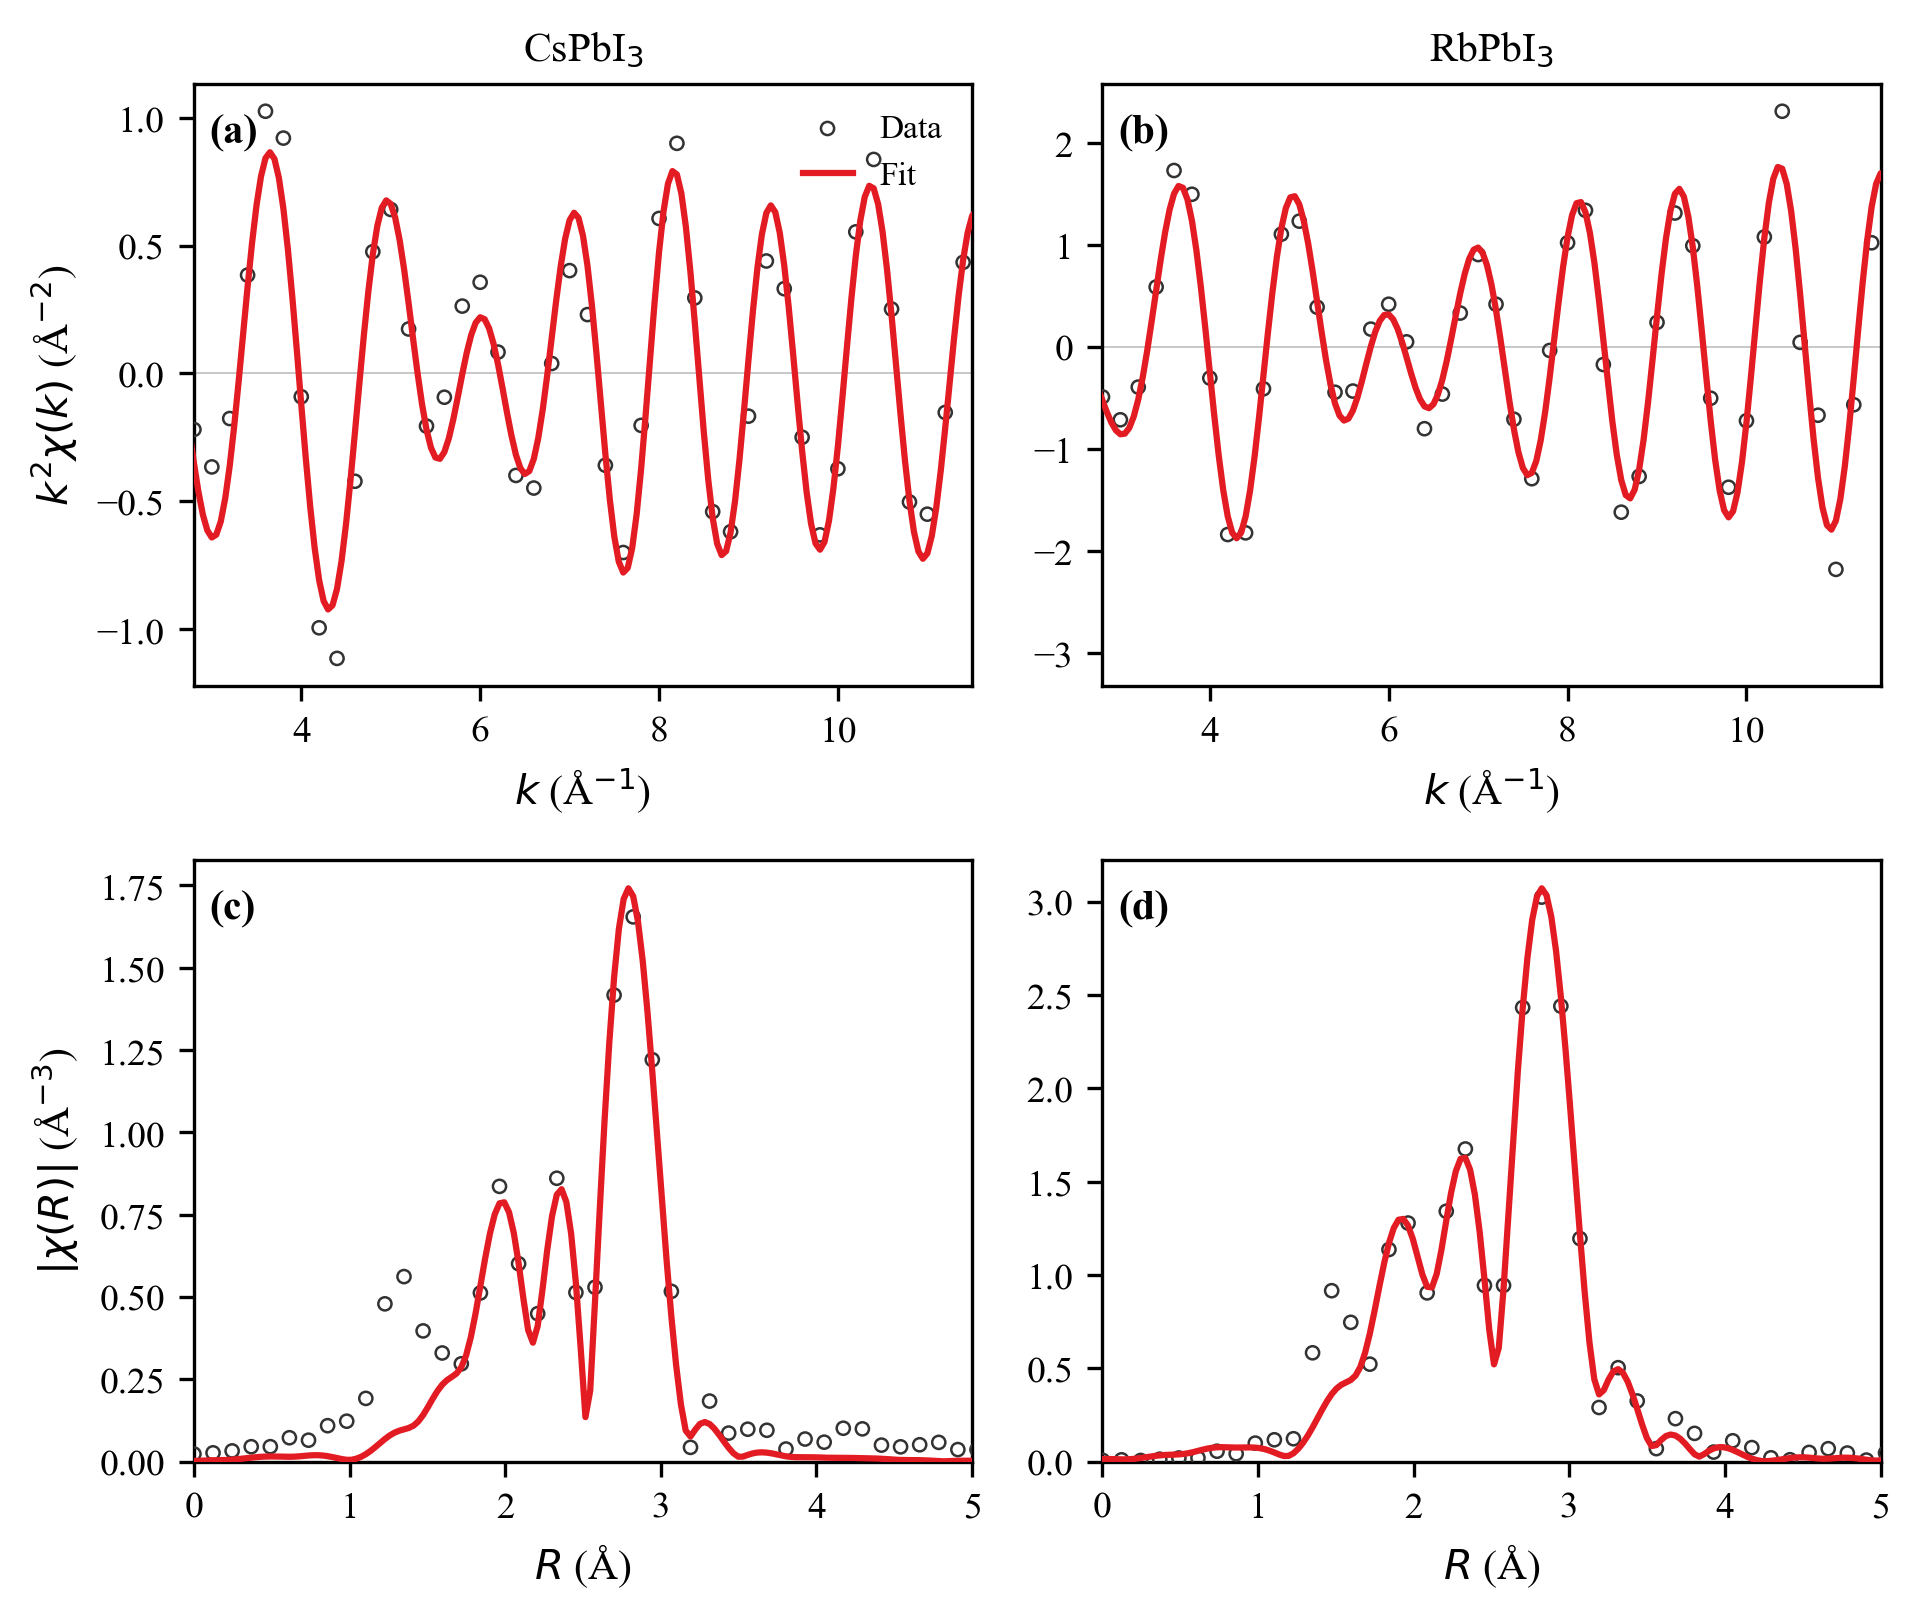

Saved: C:\Users\kwill\Keenan_UCB-O365\OneDrive - UCB-O365\Data\XAS\NSLS-II\AthenaProjectFiles\fits\Figure_combined_EXAFS_fits.png


In [ ]:
# Combined 2x2 figure: k-space and R-space magnitude for both samples
fig, axes = plt.subplots(2, 2, figsize=(7, 6))

samples = ['CsPbI3', 'RbPbI3']
plot_types = ['chiK', 'chiR']
ylabels = [r'$k^2\chi(k)$ (Å$^{-2}$)', r'|$\chi(R)$| (Å$^{-3}$)']
xlabels = [r'$k$ (Å$^{-1}$)', r'$R$ (Å)']

for row, sample in enumerate(samples):
    for col, (plot_type, ylabel, xlabel) in enumerate(zip(plot_types, ylabels, xlabels)):
        ax = axes[row, col]
        
        if sample not in all_data[plot_type]:
            continue
        
        data_dict = all_data[plot_type][sample]
        
        # Find data and model columns
        data_col = None
        model_col = None
        
        for colname in data_dict.keys():
            if colname == 'sample_name':
                continue
            col_lower = colname.lower()
            if 'data' in col_lower:
                data_col = colname
            elif 'model' in col_lower:
                model_col = colname
        
        # Plot fit first
        if model_col:
            x = data_dict[model_col]['x']
            y = data_dict[model_col]['y']
            ax.plot(x, y, color=colors['model'], linewidth=1.5, 
                    linestyle='-', label='Fit', zorder=10)
        
        # Plot data (line only)
        if data_col:
            x = data_dict[data_col]['x']
            y = data_dict[data_col]['y']
            ax.plot(x, y, color=colors['data'], linewidth=1.5, label='Data', zorder=12)
        
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.4, alpha=0.5)
        
        # Set appropriate x limits
        if plot_type == 'chiK':
            ax.set_xlim(0, 14)
        else:
            ax.set_xlim(0, 5)
        
        # Add sample label
        if col == 0:
            ax.set_title(f'{sample_labels[sample]}', fontsize=10, fontweight='medium')

# Add legend to first panel
axes[0, 0].legend(loc='upper right', frameon=True, framealpha=0.95, edgecolor='none')

plt.tight_layout()
plt.savefig(data_dir / 'Figure_combined_EXAFS_fits.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(data_dir / 'Figure_combined_EXAFS_fits.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {data_dir / 'Figure_combined_EXAFS_fits.png'}")

## Figure 5: Comprehensive R-space Analysis with Scattering Paths

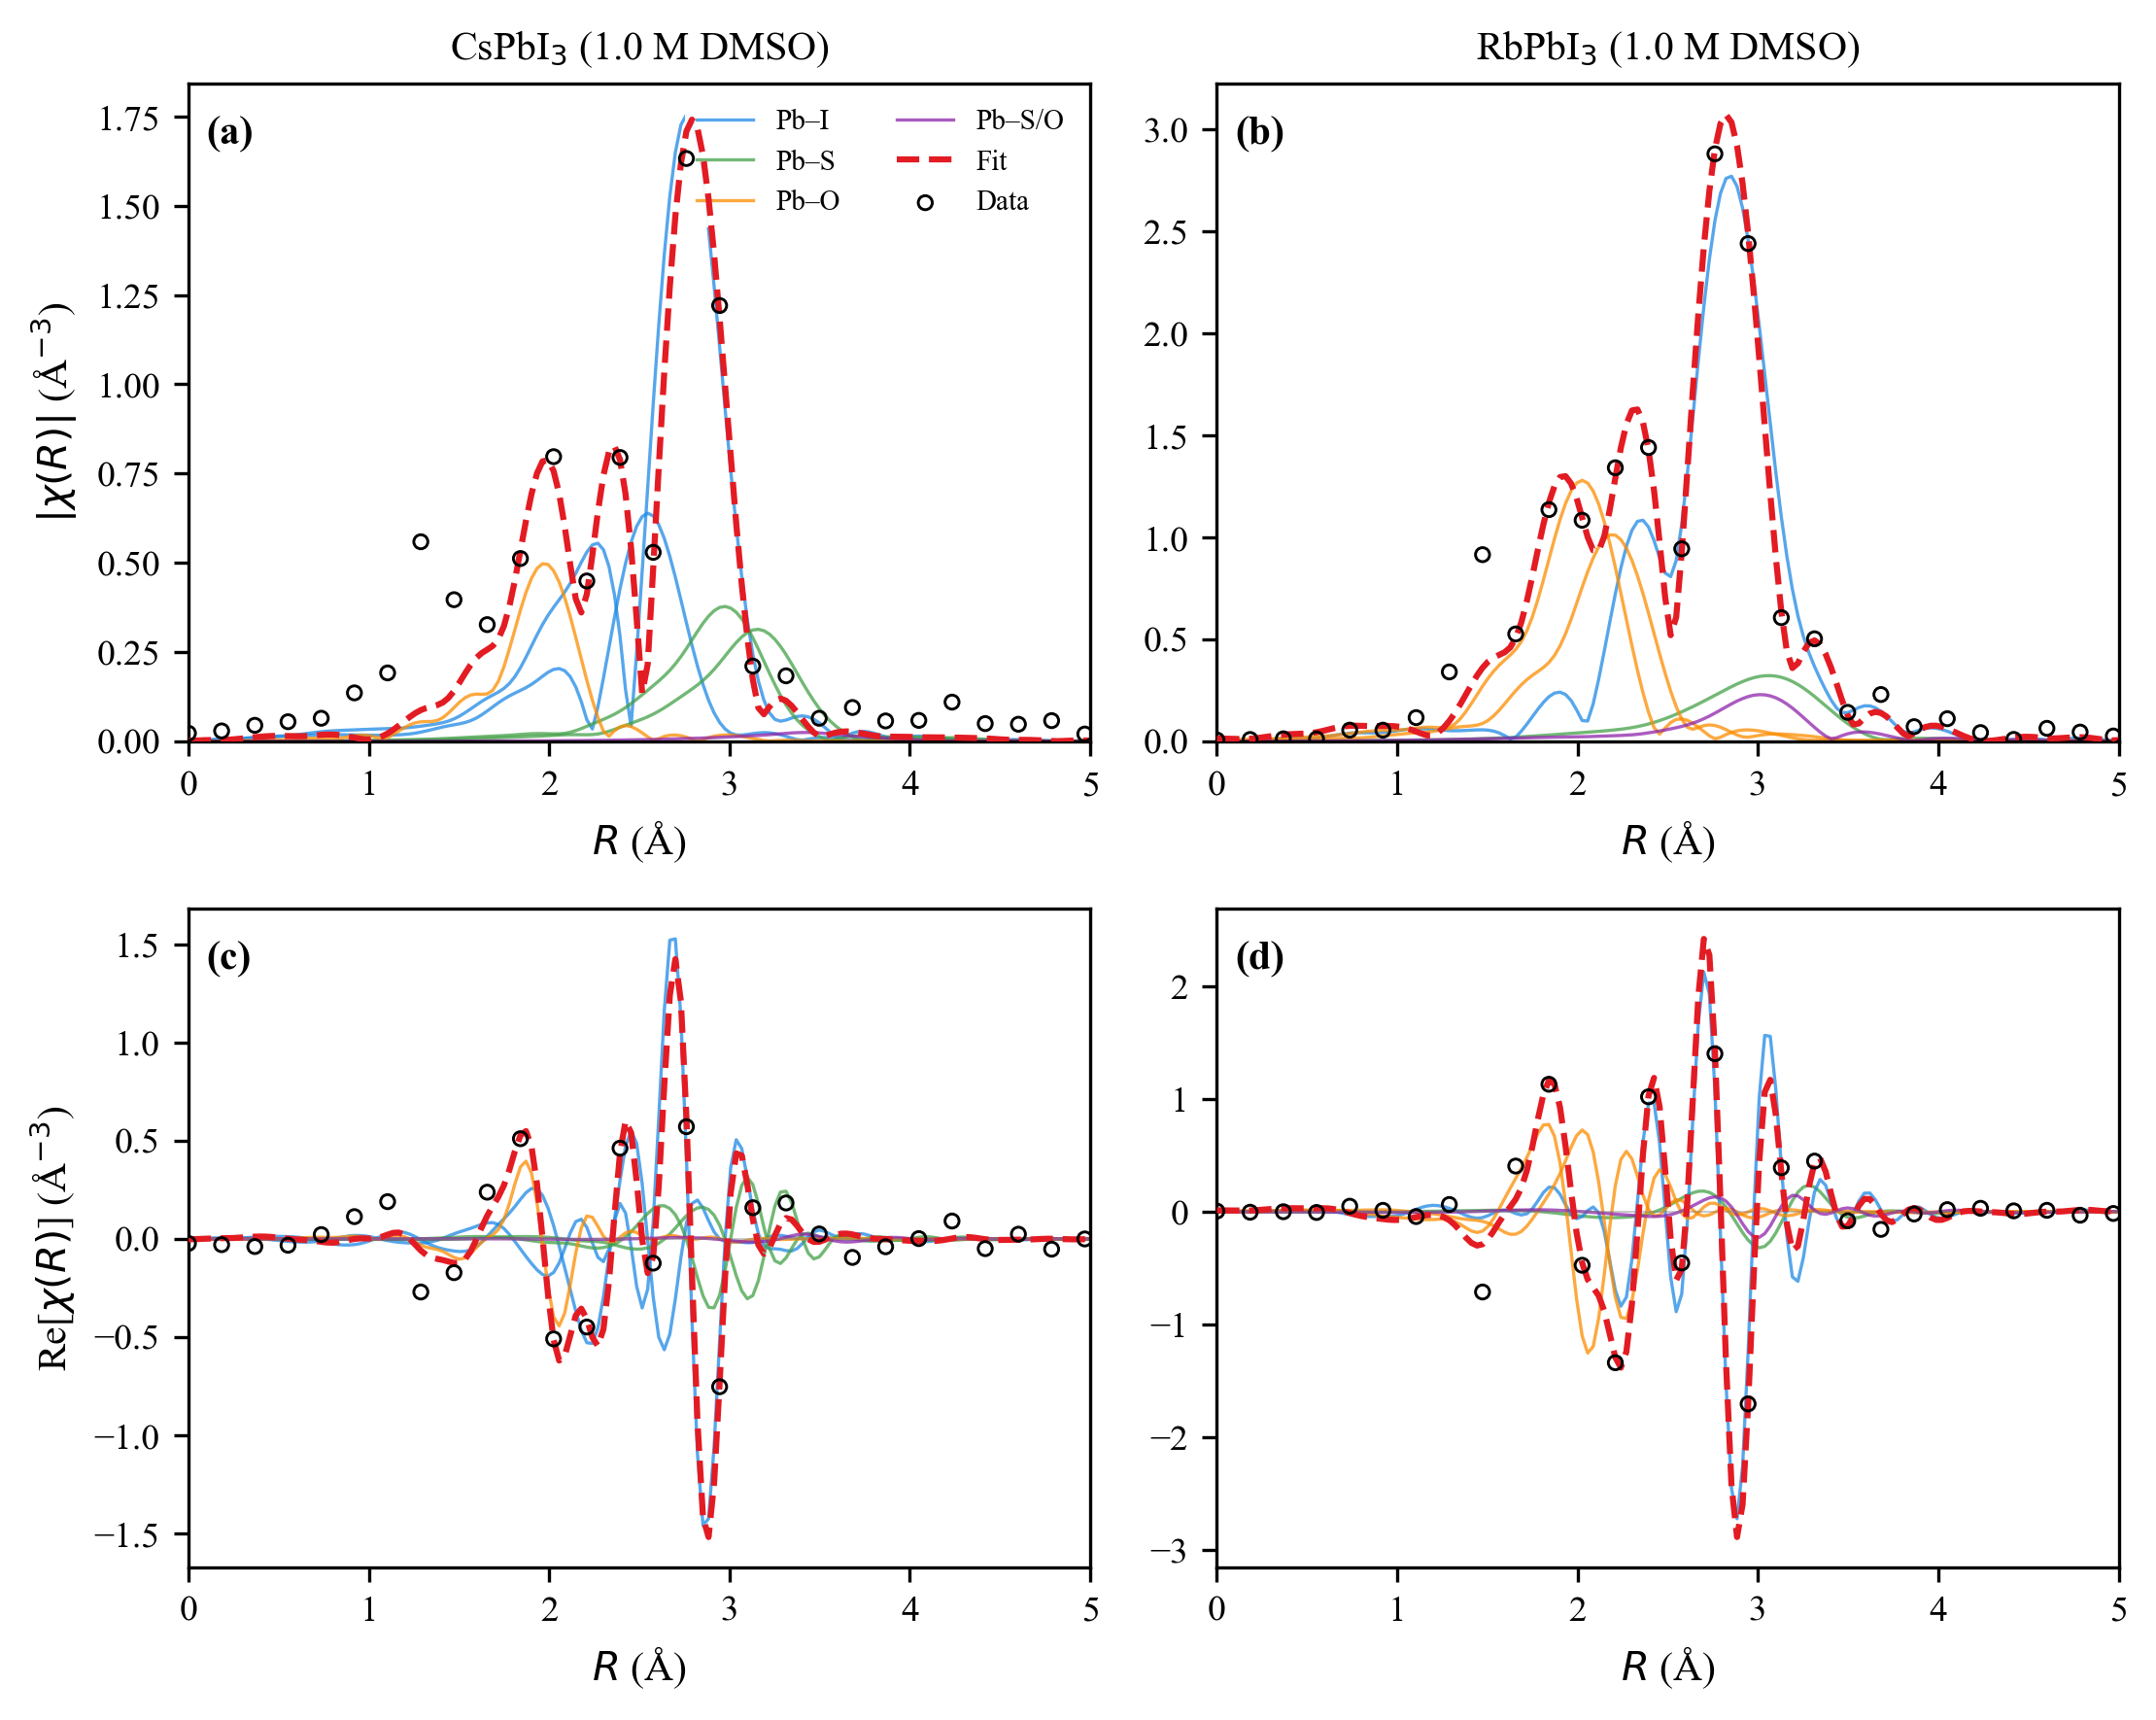

Saved: C:\Users\kwill\Keenan_UCB-O365\OneDrive - UCB-O365\Data\XAS\NSLS-II\AthenaProjectFiles\fits\Figure_comprehensive_Rspace.png


In [ ]:
# Comprehensive R-space figure: magnitude and real part for both samples
fig, axes = plt.subplots(2, 2, figsize=(7, 6), sharex=True)

samples = ['CsPbI3', 'RbPbI3']
plot_types = ['chiR', 'ReChiR']
ylabels = [r'|$\chi(R)$| (Å$^{-3}$)', r'Re[$\chi(R)$] (Å$^{-3}$)']

for col, sample in enumerate(samples):
    for row, (plot_type, ylabel) in enumerate(zip(plot_types, ylabels)):
        ax = axes[row, col]
        
        if sample not in all_data[plot_type]:
            continue
        
        data_dict = all_data[plot_type][sample]
        
        # Find data and model columns
        data_col = None
        model_col = None
        
        for colname in data_dict.keys():
            if colname == 'sample_name':
                continue
            col_lower = colname.lower()
            if 'data' in col_lower:
                data_col = colname
            elif 'model' in col_lower:
                model_col = colname
        
        # Plot fit first
        if model_col:
            x = data_dict[model_col]['x']
            y = data_dict[model_col]['y']
            ax.plot(x, y, color=colors['model'], linewidth=1.5, 
                    linestyle='-', label='Fit', zorder=10)
        
        # Plot data (line only)
        if data_col:
            x = data_dict[data_col]['x']
            y = data_dict[data_col]['y']
            ax.plot(x, y, color=colors['data'], linewidth=1.5, label='Data', zorder=12)
        
        ax.set_ylabel(ylabel)
        ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.4, alpha=0.5)
        ax.set_xlim(0, 5)
        
        # Add sample label to top row
        if row == 0:
            ax.set_title(f'{sample_labels[sample]}', fontsize=10, fontweight='medium')
        
        # Add x label to bottom row
        if row == 1:
            ax.set_xlabel(r'$R$ (Å)')

# Add legend to first panel
axes[0, 0].legend(loc='upper right', frameon=True, framealpha=0.95, edgecolor='none')

plt.tight_layout()
plt.savefig(data_dir / 'Figure_comprehensive_Rspace.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(data_dir / 'Figure_comprehensive_Rspace.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {data_dir / 'Figure_comprehensive_Rspace.png'}")

## Plotting EXAFS Fits